Step size: 0.01
Max Eigenvalue Magnitude: 1.0000
Solution may not be Entirely Stable ;)


Step size: 0.1
Max Eigenvalue Magnitude: 1.0050
Solution may not be Entirely Stable ;)


Step size: 0.5
Max Eigenvalue Magnitude: 1.1180
Solution may not be Entirely Stable ;)


Step size: 1.0
Max Eigenvalue Magnitude: 1.4142
Solution may not be Entirely Stable ;)




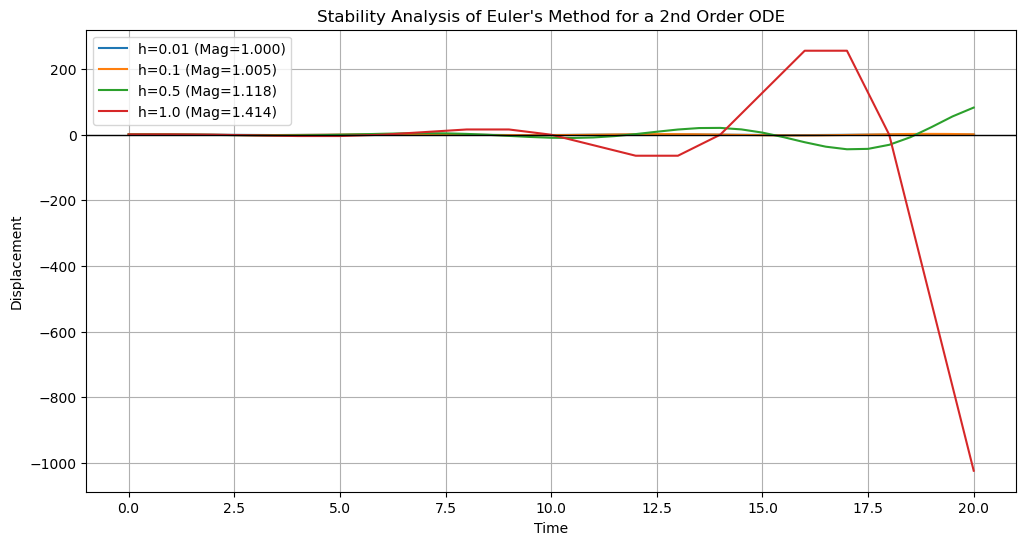

In [5]:
import numpy as np
import matplotlib.pyplot as plt

k = 1.0  
h_values = [0.01, 0.1, 0.5, 1.0] 
t_start = 0
t_end = 20
y_0 = 1.0 
v_0 = 0.0 

def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)
        
    return t_values, y_values

plt.figure(figsize=(12, 6))

for h in h_values:
    A = np.array([[1, h], [-k*h, 1]])
    eigenvalues = np.linalg.eigvals(A)
    max_eigenvalues = max(abs(eigenvalues))
    print(f"Step size: {h}")
    print(f"Max Eigenvalue Magnitude: {max_eigenvalues:.4f}")
    if max_eigenvalues <= 1.0:
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")
    print("\n")
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'h={h} (Mag={max_eigenvalues:.3f})')

plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title("Stability Analysis of Euler's Method for a 2nd Order ODE")
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.show()